In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import *
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.plot import *
from mis_dro.results import *
from mis_dro.experiments import ExperimentName
from mis_dro.main import get_npl_uuid, POSTERIOR_GB_COLS

from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":20})
rc('text', usetex=True)

In [3]:
experiment_name = ExperimentName.mmd_portfolio_synthetic
mmd_experiment_dir = Path(f"/Users/patrick/experiments/misdro/2025_01_30_robas/2025_01_30_{experiment_name.value}")
npl_samples_dir = Path(f"/Users/patrick/experiments/misdro/2025_01_30_robas/2025_01_30_{experiment_name.value}_samples")
assert mmd_experiment_dir.exists()
assert npl_samples_dir.exists()
with open(mmd_experiment_dir / "experiment.json", "r", encoding="utf-8") as json_file:
    experiment = json.load(json_file)
mmd_results_df = pd.read_csv(mmd_experiment_dir / "results.csv", index_col=["uuid", "replication"])

kl_experiment_dir = Path("/Users/patrick/experiments/misdro/2025_01_30_robas/2025_01_30_kl_portfolio_synthetic")
assert kl_experiment_dir.exists()
kl_results_df = pd.read_csv(kl_experiment_dir / "results.csv", index_col=["uuid", "replication"])

all_results_df = pd.concat([mmd_results_df, kl_results_df])
all_results_df

solution  \
uuid                                 replication                                                      
d7c30c4e-55cd-49cc-b367-5efb0ca9b232 0            [4.841130485487702e-10, 5.49784132181331e-11, ...   
                                     1            [1.4641851541547909e-09, 1.9682222294998499e-1...   
                                     2            [7.951415370405964e-09, 1.8603671254294924e-09...   
                                     3            [6.575458506808176e-09, 2.056282323725123e-09,...   
                                     4            [1.7853308551465308e-09, 5.434243493616854e-10...   
...                                                                                             ...   
e2c3d800-fbb4-49b7-aace-bfcc0d9ae767 95           [0.862486024105865, 0.00412279111832487, 2.783...   
                                     96           [0.8318875360262764, 0.027169292429852318, 3.5...   
                                     97           [0.7814720188221241, 0.025510759005416647, 0.0...   
                                     98           [0.9043450959917588, 1.7191567889817594e-07, 0...   
                                     99           [0.8513621885101937, 0.0024271627486246185, 6....   

                                                  dgp_time  likelihood_time  \
uuid                                 replication                              
d7c30c4e-55cd-49cc-b367-5efb0ca9b232 0            0.045061         0.022879   
                                     1            0.015258         0.023440   
                                     2            0.061959         0.021021   
                                     3            0.061487         0.021708   
                                     4            0.004530         0.026413   
...                                                    ...              ...   
e2c3d800-fbb4-49b7-aace-bfcc0d9ae767 95           0.002316         0.000002   
                                     96           0.002169         0.000002   
                                     97           0.002428         0.000002   
                                     98           0.002261         0.000001   
                                     99           0.002406         0.000002   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
d7c30c4e-55cd-49cc-b367-5efb0ca9b232 0                  0.002836  309.999903   
                                     1                  0.035435  246.052469   
                                     2                  0.047304  247.669338   
                                     3                  0.051295  259.174208   
                                     4                  0.014964  256.856195   
...                                                          ...         ...   
e2c3d800-fbb4-49b7-aace-bfcc0d9ae767 95                 0.002229    0.272913   
                                     96                 0.002177    0.273998   
                                     97                 0.002303    0.329497   
                                     98                 0.002258    0.335924   
                                     99                 0.002307    0.175060   

                                                  setup_time  \
uuid                                 replication               
d7c30c4e-55cd-49cc-b367-5efb0ca9b232 0                   NaN   
                                     1                   NaN   
                                     2                   NaN   
                                     3                   NaN   
                                     4                   NaN   
...                                                      ...   
e2c3d800-fbb4-49b7-aace-bfcc0d9ae767 95                  NaN   
                                     96                  NaN   
                                     97   

In [4]:
# NOTE filter by DGP
filter_dgp = "portfolio_contaminated_multivariate_normal"
dataset = "portfolio_synthetic"
# assert filter_dgp in all_results_df["dgp"] and dataset in all_results_df["dataset"]
results_df = preprocess_results_df(all_results_df, filter_dgp, dataset=dataset)
agg_df = get_agg_df(results_df, ["algorithm", "contamination", "epsilon", "inference"])
agg_df

/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function mean at 0x1183e7100> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/Users/patrick/Projects/mis-dro-code/mis_dro/results.py:66: FutureWarning: The provided callable <function std at 0x1183e7240> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  agg_df = gb.agg(


out_of_sample_mean  \
algorithm   contamination epsilon inference                       
dro_bas_mmd 0.0           0.0001  npl_mmd              3.410948   
                          0.0010  npl_mmd              3.414156   
                          0.0050  npl_mmd              3.409118   
                          0.0100  npl_mmd              3.395737   
                          0.0500  npl_mmd              3.304028   
...                                                         ...   
kl_pp       0.2           1.0000  bayes                2.541212   
                          1.5000  bayes                2.535754   
                          2.0000  bayes                2.532018   
                          2.5000  bayes                2.529150   
                          3.0000  bayes                2.525177   

                                             out_of_sample_var  \
algorithm   contamination epsilon inference                      
dro_bas_mmd 0.0           0.0001  npl_mmd            28.439611   
                          0.0010  npl_mmd            28.439175   
                          0.0050  npl_mmd            28.217365   
                          0.0100  npl_mmd            27.624315   
                          0.0500  npl_mmd            22.559379   
...                                                        ...   
kl_pp       0.2           1.0000  bayes               4.096946   
                          1.5000  bayes               4.118228   
                          2.0000  bayes               4.133811   
                          2.5000  bayes               4.147402   
                          3.0000  bayes               4.162537   

                                             out_of_sample_std  \
algorithm   contamination epsilon inference                      
dro_bas_mmd 0.0           0.0001  npl_mmd             5.332880   
                          0.0010  npl_mmd             5.332839   
                          0.0050  npl_mmd             5.312002   
                          0.0100  npl_mmd             5.255884   
                          0.0500  npl_mmd             4.749671   
...                                                        ...   
kl_pp       0.2           1.0000  bayes               2.024091   
                          1.5000  bayes               2.029342   
                          2.0000  bayes               2.033178   
                          2.5000  bayes               2.036517   
                          3.0000  bayes               2.040230   

                                             sum_of_in_group_var  \
algorithm   contamination epsilon inference                        
dro_bas_mmd 0.0           0.0001  npl_mmd              28.086678   
                          0.0010  npl_mmd              28.090808   
                          0.0050  npl_mmd              27.871665   
                          0.0100  npl_mmd              27.279302   
                          0.0500  npl_mmd              22.260002   
...                                                          ...   
kl_pp       0.2           1.0000  bayes                 4.052548   
                          1.5000  bayes                 4.072521   
                          2.0000  bayes                 4.086999   
                          2.5000  bayes                 4.099864   
                          3.0000  bayes                 4.113818   

                                             var_of_in_group_mean  \
algorithm   contamination epsilon inference                         
dro_bas_mmd 0.0           0.0001  npl_mmd                0.352933   
                          0.0010  npl_mmd                0.348368   
                          0.0050  npl_mmd                0.345700   
                          0.0100  npl_mmd                0.345013   
                          0.0500  npl_mmd                0.299377   
...                                                           ...   
kl_pp       0.2   

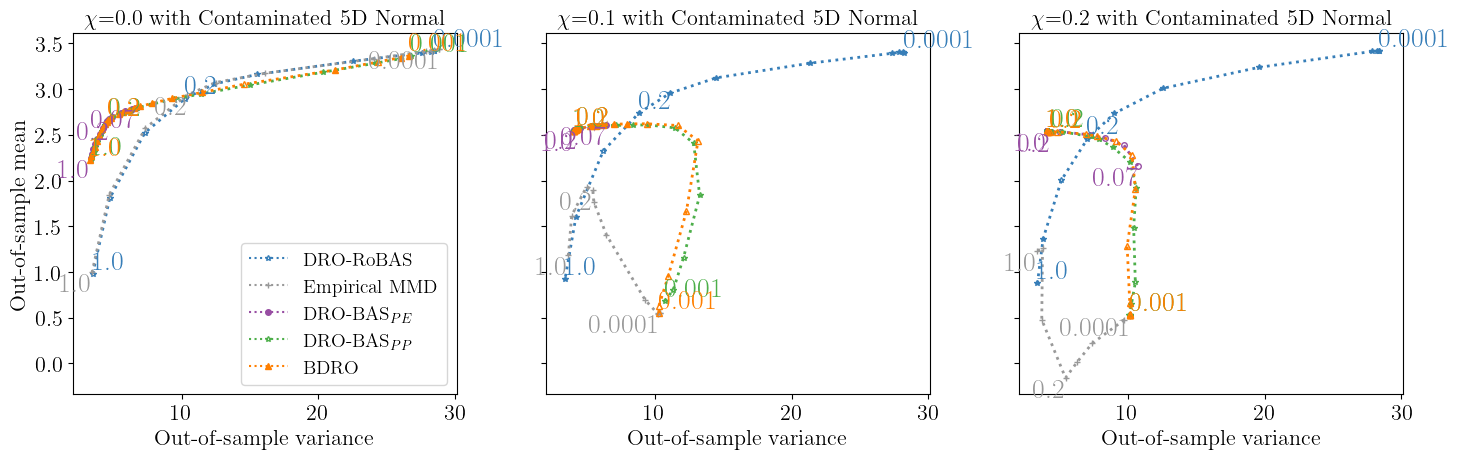

In [11]:
contamination_list = agg_df.index.get_level_values("contamination").unique().tolist()
nrows = 1
ncols = len(contamination_list)
trim_epsilon = 1.0
total_samples = 100
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15,5), sharey=True, sharex=True)
fig.subplots_adjust(wspace=0.05)
pd.options.mode.chained_assignment = None  # default='warn'
trim_epsilon = 1.0
for j, contamination in enumerate(contamination_list):
    axis_df = agg_df.loc[:, contamination, :, :] #
    axis_df.loc[:, "is_pareto_front"] = is_maximise_pareto_front(axis_df["out_of_sample_var"].values, axis_df["out_of_sample_mean"].values)
    # for (algorithm, inference) in set(zip(axis_df.index.get_level_values("algorithm"), axis_df.index.get_level_values("inference"))):
    for (algorithm, inference) in [('dro_bas_mmd', "npl_mmd"), ('empirical_mmd', "empirical"), ('kl_dro_bas', "bayes"), ('kl_pp', "bayes"), ('kl_bdro', "bayes")]:
        df = axis_df.loc[algorithm, :trim_epsilon, inference]
        alpha = 1.0
        is_labelled=True
        mean_variance_plot(axes[j], df, **algorithm_inference_style(algorithm, inference, label_inference=False), offset=0.0, is_labelled=is_labelled, alpha=alpha, special_epsilons=[0.2])
    if j == 0:
        axes[j].legend(fontsize=14)
        axes[j].set_ylabel("Out-of-sample mean", fontsize=16)
        
    axes[j].set_title("$\chi$" + f"={contamination} with {NiceNameDGP[filter_dgp]}", fontsize=16)
    axes[j].set_xlabel("Out-of-sample variance", fontsize=16)
    axes[j].tick_params(axis='both', which='major', labelsize=12)
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=16)
fig.tight_layout()
# plt.show()
# fig.savefig(f"/Users/patrick/Experiments/misdro/2025_01_30_robas/{experiment_name}.pdf", bbox_inches="tight")
fig.savefig(f"/Users/patrick/Documents/phd-thesis/figures/robas/{experiment_name}.pdf", bbox_inches="tight")

In [6]:
idx = 10
dgp = experiment[idx]["dgp"]
num_observations = experiment[idx]["num_observations"]
contamination = experiment[idx]["contamination"]
dim = experiment[idx]["dim"]
replication = 0
generator = np.random.default_rng(replication)
data = sample_dgp(
    dgp, num_observations, dim=dim, contamination=contamination, generator=generator
)
dgp_mean = np.array([0.0, 1.5, -1.0, -3.0, 3.5])
dgp_mean_outl = dgp_mean + np.array([0.0, 50.0, 50.0, 50.0, 0.0])
dgp_cov = np.diag(np.array([1.0, 1.0, 1.0, 2.0, 3.0]))
print(json.dumps(experiment[idx], indent=4))

{
    "algorithm": "dro_bas_mmd",
    "contamination": 0.0,
    "dataset": "portfolio_synthetic",
    "dgp": "portfolio_contaminated_multivariate_normal",
    "dim": 5,
    "epsilon": 1.0,
    "eta": 0.1,
    "inference": "npl_mmd",
    "lengthscale": -1.0,
    "likelihood": "multivariate_normal",
    "normalise": false,
    "num_certify_points": 200,
    "num_likelihood_samples": 10,
    "num_observations": 100,
    "num_posterior_samples": 90,
    "num_replications": 100,
    "num_test_observations": 100,
    "posterior": "npl",
    "uuid": "00d88118-a74e-47e1-9a25-c16f922cc7f3"
}


In [7]:
# train a bayesian model with normal likelihood and NIW posterior
bayes_posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(bayes_posterior, dim=dim)
theta_posterior = get_posterior_params(bayes_posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior
expected_Sigma = Psi_post / (iota_post - Psi_post.shape[0] - 1)

In [8]:
# load one NPL posterior sample
posterior_df = pd.read_csv(npl_samples_dir / "npl_settings.csv").set_index(POSTERIOR_GB_COLS)
npl_params = {key: experiment[idx][key] for key in POSTERIOR_GB_COLS}
npl_uuid = get_npl_uuid(posterior_df, npl_params)
npl_uuid_dir = npl_samples_dir / npl_uuid
path_to_csv = npl_uuid_dir / f"npl_sample_{replication}.csv"
theta_sample = pd.read_csv(path_to_csv, index_col=False, header=None).values
i = 0
npl_mu = theta_sample[i,:dim]
vec_cov = theta_sample[i,dim:]
npl_cov = cholesky_param_to_covariance(dim, vec_cov)
npl_cov

KeyError: "None of ['kernel_name'] are in the columns"

Text(0.5, 1.0, 'Bayes posterior')

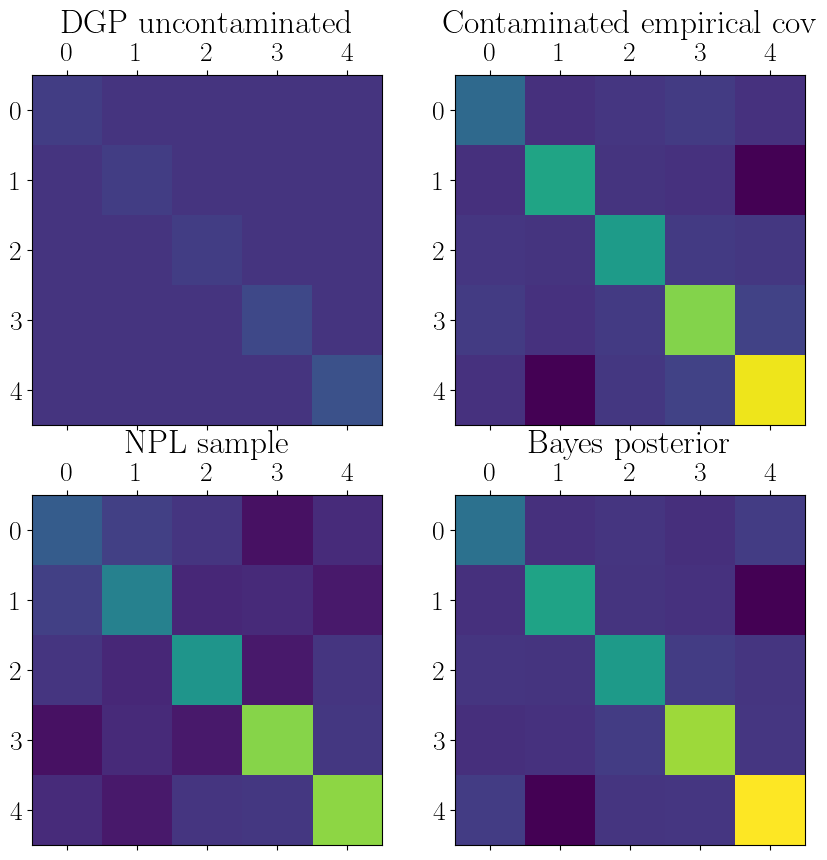

In [ ]:
# plot the posterior against the DGP
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))
all_covs = np.concatenate([dgp_cov, expected_Sigma, np.cov(data.T), npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0][0].matshow(dgp_cov, vmin=vmin, vmax=vmax)
axes[0][0].set_title("DGP uncontaminated")

axes[0][1].matshow(np.cov(data.T), vmin=vmin, vmax=vmax)
axes[0][1].set_title("Contaminated empirical cov")

axes[1][0].matshow(npl_cov, vmin=vmin, vmax=vmax)
axes[1][0].set_title("NPL sample")

axes[1][1].matshow(expected_Sigma, vmin=vmin, vmax=vmax)
axes[1][1].set_title("Bayes posterior")

Text(0.5, 1.0, 'NPL sample')

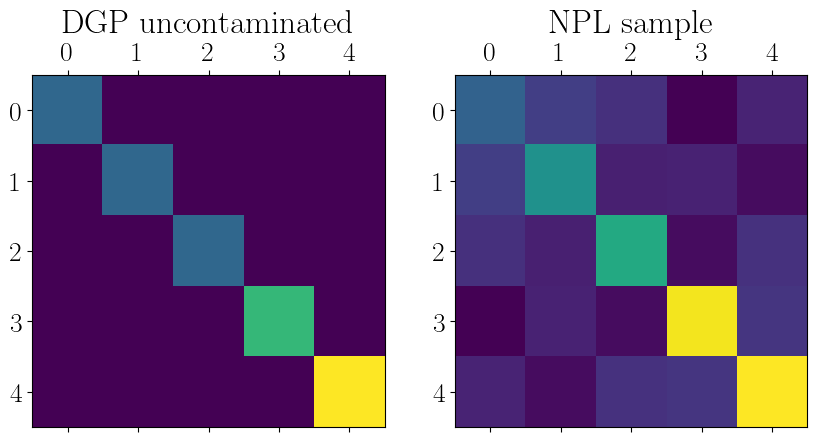

In [ ]:
# plot the posterior against the DGP
fig, axes = plt.subplots(ncols=2, figsize=(10, 5))
all_covs = np.concatenate([dgp_cov, npl_cov])
vmax = np.max(all_covs)
vmin = np.min(all_covs)

axes[0].matshow(dgp_cov)
axes[0].set_title("DGP uncontaminated")

axes[1].matshow(npl_cov)
axes[1].set_title("NPL sample")
